# [JSON](https://es.wikipedia.org/wiki/JSON)

```
# El element raíz debe ser un objeto o un array
{
  "departamento":8,
  "nombredepto":"Ventas",
  "director": "Juan Rodríguez",
  "esSenior": true,
  "empleados":[
    {
      "nombre":"Pedro",
      "apellido":"Fernández"
    },{
      "nombre":"Jacinto",
      "apellido":null
    }
  ]
}
```

In [56]:
import json

data = {
  "departamento":8,
  "nombredepto":"Ventas",
  "director": "Juan Rodríguez",
  "empleados":[
    {
      "nombre":"Pedro",
      "apellido":"Fernández"
    },{
      "nombre":"Jacinto",
      "apellido":"Benavente"
    }
  ]
}

type(data)

dict

## Serialización

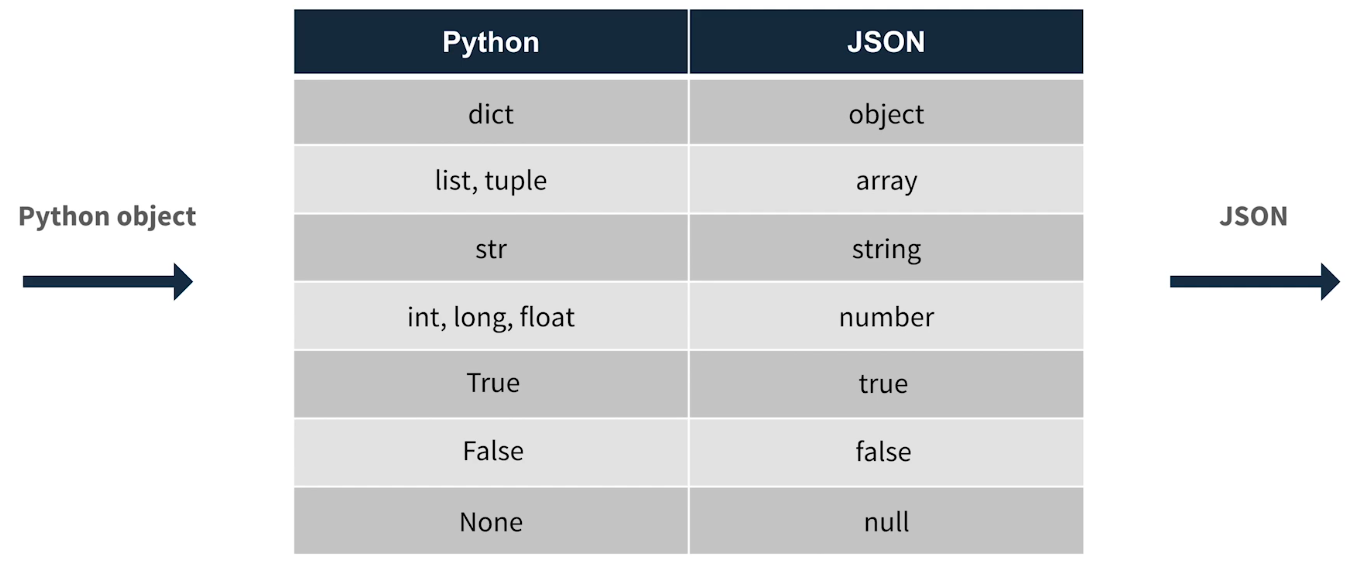

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_FOLDER = "/content/drive/My Drive/Colab Notebooks/SIS-251/02_extracción/02_web_scraping_and_webservices"

In [58]:
with open(f"{DATA_FOLDER}/data.json", "w") as write_file:
    json.dump(data, write_file)

In [59]:
json_string = json.dumps(data, indent=3)
json_string

'{\n   "departamento": 8,\n   "nombredepto": "Ventas",\n   "director": "Juan Rodr\\u00edguez",\n   "empleados": [\n      {\n         "nombre": "Pedro",\n         "apellido": "Fern\\u00e1ndez"\n      },\n      {\n         "nombre": "Jacinto",\n         "apellido": "Benavente"\n      }\n   ]\n}'

## Deserialización

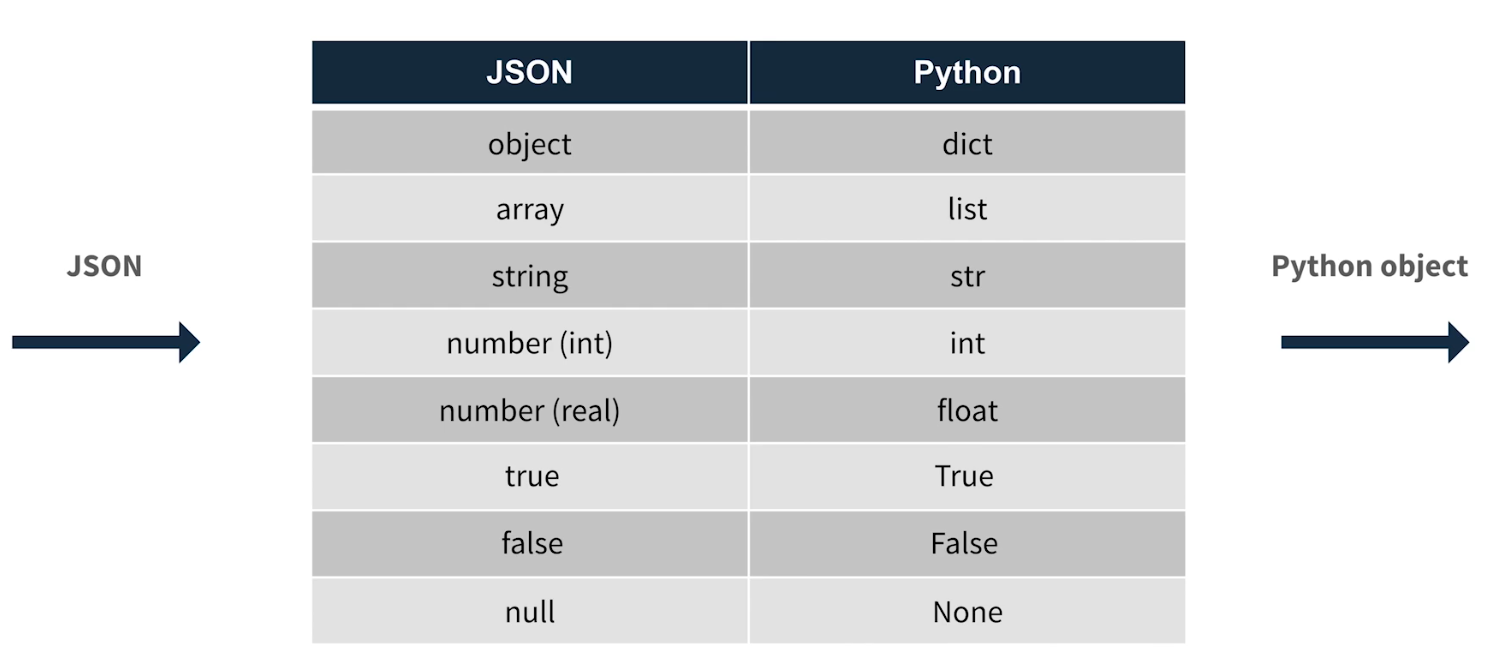

In [60]:
data["teléfonos"] = (12345678, 87654321)
print(data)

{'departamento': 8, 'nombredepto': 'Ventas', 'director': 'Juan Rodríguez', 'empleados': [{'nombre': 'Pedro', 'apellido': 'Fernández'}, {'nombre': 'Jacinto', 'apellido': 'Benavente'}], 'teléfonos': (12345678, 87654321)}


In [61]:
json_string = json.dumps(data)
json_string

'{"departamento": 8, "nombredepto": "Ventas", "director": "Juan Rodr\\u00edguez", "empleados": [{"nombre": "Pedro", "apellido": "Fern\\u00e1ndez"}, {"nombre": "Jacinto", "apellido": "Benavente"}], "tel\\u00e9fonos": [12345678, 87654321]}'

In [62]:
#'teléfonos' no es una tupla; es una lista.
# La serialización y deserialización no son procesos perfectamente inversos.
data_desde_json = json.loads(json_string)
print(type(data_desde_json))
data_desde_json

<class 'dict'>


{'departamento': 8,
 'nombredepto': 'Ventas',
 'director': 'Juan Rodríguez',
 'empleados': [{'nombre': 'Pedro', 'apellido': 'Fernández'},
  {'nombre': 'Jacinto', 'apellido': 'Benavente'}],
 'teléfonos': [12345678, 87654321]}

In [ ]:
type(data_desde_json)

dict

# HTTP/REST APIs

In [63]:
import requests

URL = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-03-01&endtime=2026-03-02"
response = requests.get(URL)

In [66]:
# response.text

In [67]:
# json.loads(response.text)

In [68]:
data = response.json()

In [69]:
type(data)

dict

# JMESPath - JSON Matching Expression paths

Lenguaje de consulta para buscar en documentos JSON. Permite [extraer elementos de forma declarativa de un documento JSON](https://jmespath.org/tutorial.html), similar a XPath o BeatifulSoup para XML/HTML. Permite seleccionar y extraer datos de un documento JSON de manera similar BeatifulSoup permite hacer con HTML.

Instalar paquete para ejecutar consultas [JMESPath](https://anaconda.org/anaconda/jmespath) en un entorno de Python:

```
pip install jmespath
```


In [70]:
# Está instalado?
!pip list | grep jmespath

jmespath                                 1.1.0


In [ ]:
# !pip install jmespath

In [29]:
import jmespath

object = {"a": {"b": {"c": {"d": "value"}}}}

In [30]:
# No funciona pasando una cadena JSON :(
jmespath.search("a.b.c.d", json.dumps(object))

In [31]:
jmespath.search("a", object)

{'b': {'c': {'d': 'value'}}}

In [32]:
jmespath.search("a.b", object)

{'c': {'d': 'value'}}

In [33]:
#Seleccionar una clave
jmespath.search("a.b.c.d", object)

'value'

In [34]:
list = ["a", "b", "c", "d", "e", "f"]

In [35]:
# jmespath.search("[1]", list)
# jmespath.search("[-1]", list)
# jmespath.search("[1:4]", list)
# jmespath.search("[::2]", list)
# jmespath.search("[::-1]", list)

In [36]:
complex_data = {"a": {
    "b": {
      "c": [
        {"d": [0, [1, 2]]},
        {"d": [3, 4]}
      ]
    }
  }
}

In [37]:
jmespath.search("a.b.c", complex_data)

[{'d': [0, [1, 2]]}, {'d': [3, 4]}]

In [38]:
jmespath.search("a.b.c[0].d[1][1]", complex_data)

2

In [48]:
persons_data = {
   "persons": [
    { "name": "Juan", "age": 38, "cityOfBirth": {"country": "BO", "city": "Sucre"} },
    { "name": "Eileen", "age": 20, "cityOfBirth": {"country": "BO", "city": "Cochabamba"} },
    { "name": "Matias", "age": 14, "cityOfBirth": {"country": "AR", "city": "Salta"} }
  ],
  "foo": {"bar": "baz"}
}

In [49]:
# jmespath.search('persons[*].age', persons_data)

In [41]:
# jmespath.search('persons[:2].name', persons_data)

In [42]:
# Multi-select as list
# jmespath.search('persons[:2].[name, cityOfBirth.country, cityOfBirth.city]', persons_data)

In [43]:
# Multi-select as dictionary
# jmespath.search('persons[:2].{name:name, country:cityOfBirth.country}', persons_data)

In [71]:
operations = {
  "ops": {
    "functionA": {"numArgs": 2},
    "functionB": {"numArgs": 3},
    "functionC": {"variadic": True}
  }
}

In [72]:
jmespath.search('ops.*.numArgs', operations)

[2, 3]

In [73]:
persons_data

{'persons': [{'name': 'Juan',
   'age': 38,
   'cityOfBirth': {'country': 'BO', 'city': 'Sucre'}},
  {'name': 'Eileen',
   'age': 20,
   'cityOfBirth': {'country': 'BO', 'city': 'Cochabamba'}},
  {'name': 'Matias',
   'age': 14,
   'cityOfBirth': {'country': 'AR', 'city': 'Salta'}}],
 'foo': {'bar': 'baz'}}

In [74]:
# Encadenamientos
# La segunda expresión JMESPath opera sobre el resultado de la primera
jmespath.search("persons[:2].name | [0]", persons_data)

'Juan'

In [75]:
#"persons[:2].name | [0]" en dos pasos
nombres = jmespath.search("persons[:2].name", persons_data)
jmespath.search("[0]", nombres)

'Juan'

In [51]:
persons_data

{'persons': [{'name': 'Juan',
   'age': 38,
   'cityOfBirth': {'country': 'BO', 'city': 'Sucre'}},
  {'name': 'Eileen',
   'age': 20,
   'cityOfBirth': {'country': 'BO', 'city': 'Cochabamba'}},
  {'name': 'Matias',
   'age': 14,
   'cityOfBirth': {'country': 'AR', 'city': 'Salta'}}],
 'foo': {'bar': 'baz'}}

In [80]:
# Filtros ==, !=, <, <=, >, >=
# https://jmespath.org/specification.html#builtin-functions
# jmespath.search("persons[?name=='Matias'].age", persons_data)

In [77]:
# Funciones
# https://jmespath.org/specification.html#functions
# jmespath.search("length(persons)", persons_data)

In [81]:
# jmespath.search("max_by(persons, &age)", persons_data)

{'name': 'Juan', 'age': 38, 'cityOfBirth': {'country': 'BO', 'city': 'Sucre'}}

In [ ]:
# Cuántas personas nacieron en Bolivia?

In [82]:
# jmespath.search("length(persons[?cityOfBirth.country=='BO'])", persons_data)

In [83]:
# len(jmespath.search("persons[?cityOfBirth.country=='BO']", persons_data))

In [85]:
obj_with_list = {
  "myarray": [
    "foo",
    "foobar",
    "barfoo",
    "bar",
    "baz",
    "barbaz",
    "barfoobaz"
  ]
}

In [86]:
# Se puede combinar funciones con filtros
# El carácter @ se refiere al elemento actual que se está evaluando en 'myarray'.
# jmespath.search("myarray[?contains(@, 'foo') == `true`]", obj_with_list)

['foo', 'foobar', 'barfoo', 'barfoobaz']

# Referencias

## Fuentes de datos
- [Catálogo de Datos Abiertos - Uruguay](https://catalogodatos.gub.uy/)
- [Free API – Huge List of Public APIs For Testing](https://apipheny.io/free-api/)
- [{JSON} Placeholder - Free fake API for testing and prototyping](https://jsonplaceholder.typicode.com/)
- [Public APIs - A collective list of free APIs for use in software and web development](https://github.com/public-apis/public-apis)
- [5 More Free Public APIs You Should Try](https://betterprogramming.pub/5-more-free-public-apis-you-should-try-4e701aaf80d)
- [10 Fun (and Free) APIs to Use For Your Next Coding Project](https://medium.com/geekculture/10-fun-and-free-apis-to-use-for-your-next-coding-project-7d765f643f08)
- [Public REST APIs](https://documenter.getpostman.com/view/8854915/Szf7znEe)
- [Awesome JSON Datasets](https://awesomeopensource.com/project/jdorfman/awesome-json-datasets)
- [USGS Earthquake Hazards Program - Feeds & Notifications]()

## Herramientas
- [JMESPath - JSON Matching Expression paths](https://jmespath.org/contents.html)
- [JMESPath - Online Evaluator](https://play.jmespath.org/)
- [JSON Formatter and Validator](https://jsonformatter.curiousconcept.com/)
- [Requests Quickstart](https://requests.readthedocs.io/en/latest/user/quickstart/)

## HTTP
- [HTTP Status Codes Glossary](https://www.webfx.com/web-development/glossary/http-status-codes/)